# MNIST Digit Classification

This notebook demonstrates three classification models trained on the MNIST dataset — grayscale images of handwritten digits (0–9).

All three models share a unified interface via `MnistClassifier` and support the same `train` / `predict` API:

| Algorithm | Key | Description |
|-----------|-----|-------------|
| Random Forest | `rf` | Ensemble of decision trees on flattened pixel features |
| Feed-Forward Neural Network | `nn` | 3-layer fully connected network (784 → 250 → 100 → 10) |
| Convolutional Neural Network | `cnn` | 2-block Conv2D architecture with MaxPooling |

## 1. Setup

In [3]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import logging

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from src.mnist_classifier import MnistClassifier

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logger = logging.getLogger(__name__)

## 2. Data Loading

In [4]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X = mnist["data"]
y = mnist["target"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
logger.info(f"Training samples : {X_train.shape[0]}")
logger.info(f"Test samples     : {X_test.shape[0]}")
logger.info(f"Image dimensions : {X_train.shape[1]} (28x28 flattened)")

2026-03-16 12:11:10,380 - INFO - Training samples : 56000
2026-03-16 12:11:10,381 - INFO - Test samples     : 14000
2026-03-16 12:11:10,381 - INFO - Image dimensions : 784 (28x28 flattened)


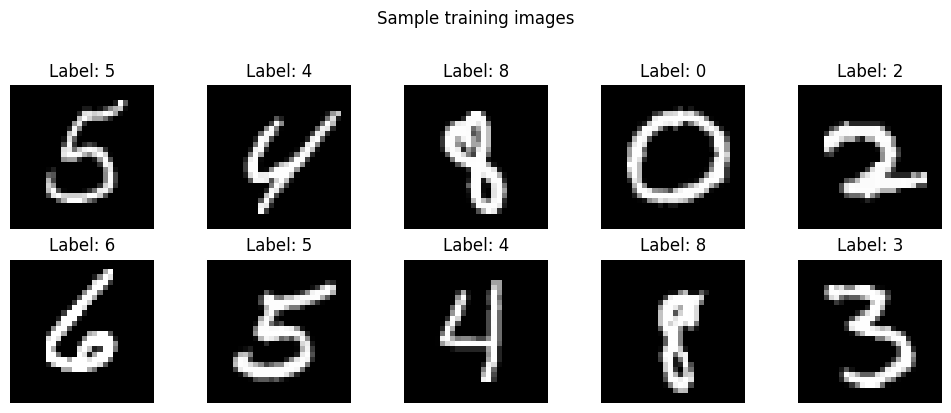

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample training images", y=1.02)
plt.tight_layout()
plt.show()

## 3. Training

### 3.1 Random Forest

In [9]:
rf_classifier = MnistClassifier(algorithm='rf')
rf_classifier.train(X_train, y_train)

rf_predictions = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
logger.info(f"Random Forest accuracy: {rf_accuracy:.4f}")

Random Forest accuracy: 0.9669


### 3.2 Feed-Forward Neural Network

In [11]:
nn_classifier = MnistClassifier(algorithm='nn')
nn_classifier.train(X_train, y_train)

nn_predictions = nn_classifier.predict(X_test)
nn_accuracy = accuracy_score(y_test, nn_predictions)
logger.info(f"Feed-Forward NN accuracy: {nn_accuracy:.4f}")

2026-03-16 12:13:03,760 - INFO - Epoch [1/5] 	 Loss: 0.2525 	 Accuracy: 92.52%
2026-03-16 12:13:05,292 - INFO - Epoch [2/5] 	 Loss: 0.0995 	 Accuracy: 97.00%
2026-03-16 12:13:06,804 - INFO - Epoch [3/5] 	 Loss: 0.0652 	 Accuracy: 97.98%
2026-03-16 12:13:08,369 - INFO - Epoch [4/5] 	 Loss: 0.0488 	 Accuracy: 98.41%
2026-03-16 12:13:09,901 - INFO - Epoch [5/5] 	 Loss: 0.0391 	 Accuracy: 98.72%
2026-03-16 12:13:09,922 - INFO - Feed-Forward NN accuracy: 0.9759


### 3.3 Convolutional Neural Network

In [12]:
cnn_classifier = MnistClassifier(algorithm='cnn')
cnn_classifier.train(X_train, y_train)

cnn_predictions = cnn_classifier.predict(X_test)
cnn_accuracy = accuracy_score(y_test, cnn_predictions)
logger.info(f"CNN accuracy: {cnn_accuracy:.4f}")

2026-03-16 12:13:41,850 - INFO - Epoch [1/5] 	 Loss: 0.2388 	 Accuracy: 92.77%
2026-03-16 12:13:53,142 - INFO - Epoch [2/5] 	 Loss: 0.0652 	 Accuracy: 98.04%
2026-03-16 12:14:04,406 - INFO - Epoch [3/5] 	 Loss: 0.0450 	 Accuracy: 98.61%
2026-03-16 12:14:15,551 - INFO - Epoch [4/5] 	 Loss: 0.0336 	 Accuracy: 98.97%
2026-03-16 12:14:26,854 - INFO - Epoch [5/5] 	 Loss: 0.0286 	 Accuracy: 99.12%
2026-03-16 12:14:27,274 - INFO - CNN accuracy: 0.9863


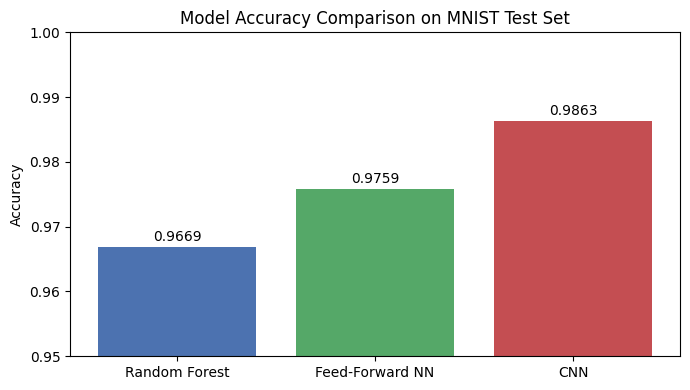

In [14]:
results = {
    'Random Forest': rf_accuracy,
    'Feed-Forward NN': nn_accuracy,
    'CNN': cnn_accuracy,
}


fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results.keys(), results.values(), color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_ylim(0.95, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison on MNIST Test Set')
for bar, acc in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Edge Cases

### 5.1 Invalid algorithm name

`MnistClassifier` raises a `ValueError` with a descriptive message when an unsupported algorithm is passed.

In [15]:
try:
    MnistClassifier(algorithm='svm')
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: Unknown algorithm 'svm'. Choose from: ['rf', 'nn', 'cnn']


In [19]:
def show_misclassified(X_test, y_true, predictions, model_name, n=10):
    y_true_arr = np.array(y_true)
    misclassified = np.where(predictions != y_true_arr)[0][:n]

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for ax, idx in zip(axes.flat, misclassified):
        ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f"True: {y_true_arr[idx]}  Pred: {predictions[idx]}", fontsize=8)
        ax.axis('off')
    plt.suptitle(f'{model_name} — misclassified samples')
    plt.tight_layout()
    plt.show()

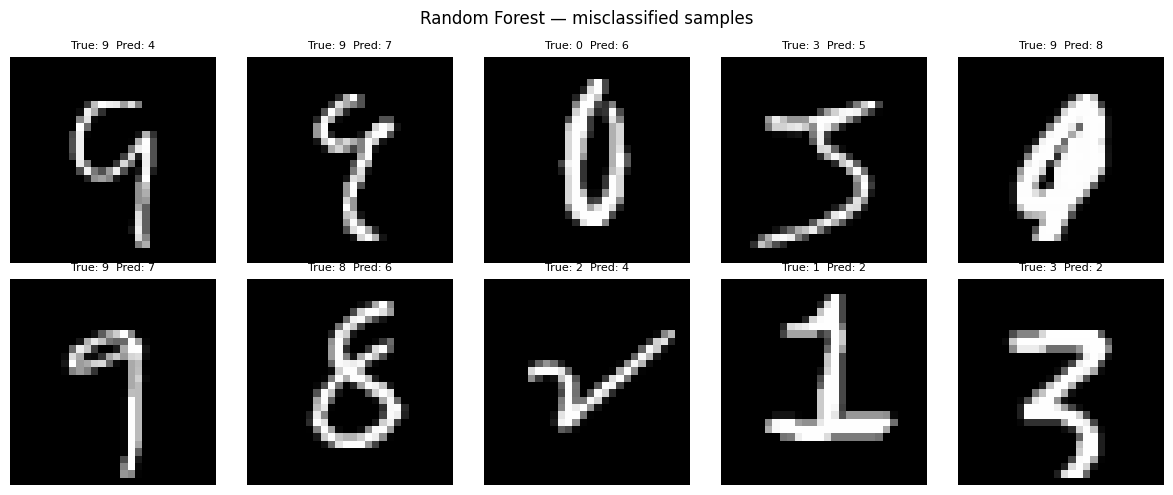

In [21]:
show_misclassified(X_test, y_test, rf_predictions,  'Random Forest')

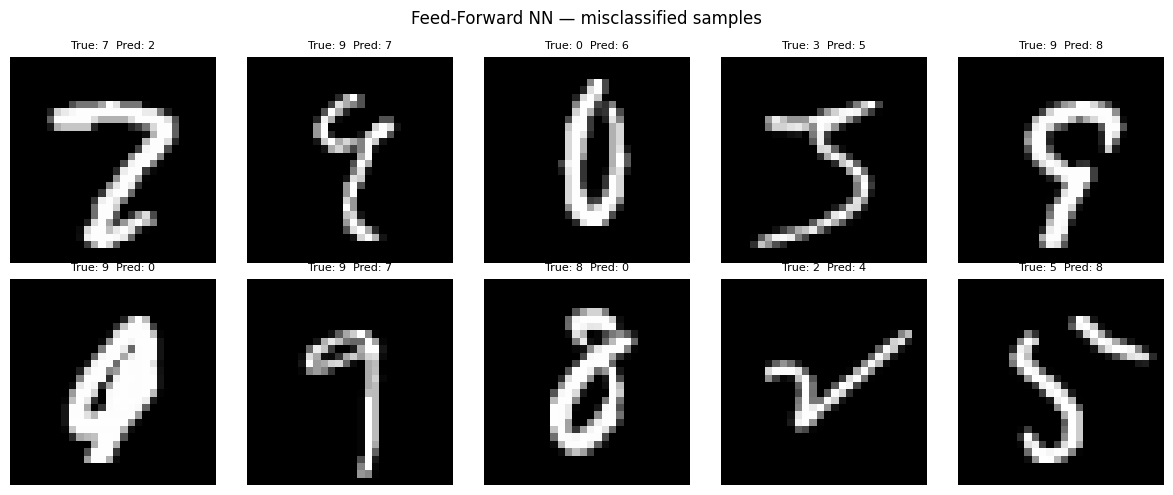

In [22]:
show_misclassified(X_test, y_test, nn_predictions,  'Feed-Forward NN')

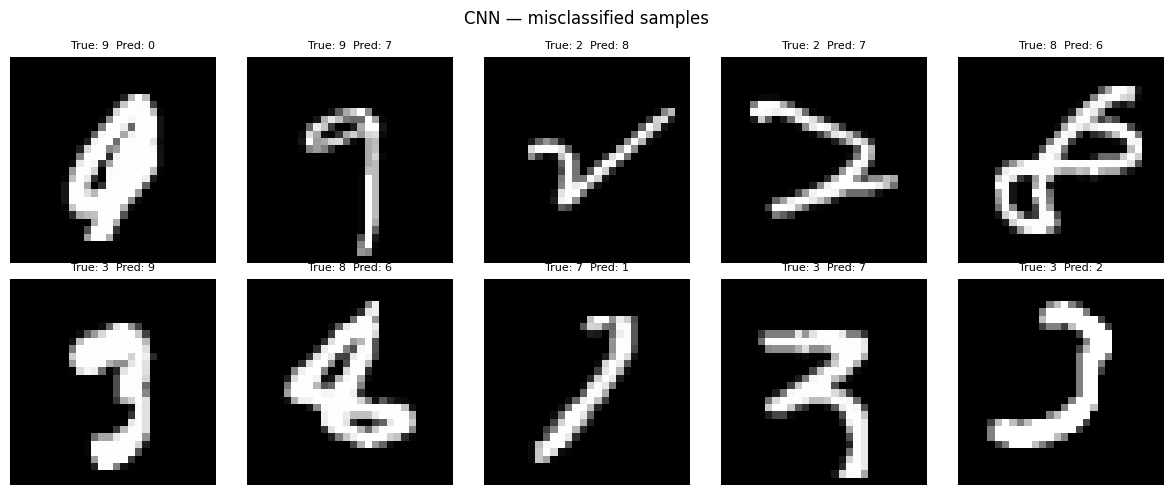

In [23]:
show_misclassified(X_test, y_test, cnn_predictions, 'CNN')